In [1]:
import tensorflow
import numpy as np
import matplotlib.pyplot as plt
import os
import time



In [2]:
#importing tensorflow libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense,GlobalAveragePooling2D,Dropout)

In [3]:
#defining the path of dataset
train_path='Face_mask_dataset/train_data'
test_path='Face_mask_dataset/test_data'
validation_path='Face_mask_dataset/validation_data'

In [4]:
#creating objects for preprocessing
dtgenerator_train = ImageDataGenerator(rescale=1./255,horizontal_flip=True)
dtgenerator_valid = ImageDataGenerator(rescale=1./255)
dtgenerator_test = ImageDataGenerator(rescale=1./255)

In [5]:
#Loading the dataset by creating the generators
trn_generator = dtgenerator_train.flow_from_directory(directory=train_path,target_size=(224,224),batch_size=32,class_mode='binary')

vld_generator = dtgenerator_valid.flow_from_directory(directory=validation_path,target_size=(224,224),batch_size=32,class_mode='binary')

tst_generator = dtgenerator_test.flow_from_directory(directory=test_path,target_size=(224,224),batch_size=32,class_mode='binary',shuffle=False)


Found 4000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Found 1553 images belonging to 2 classes.


In [6]:
print(trn_generator.samples)

4000


In [7]:
print(trn_generator.class_indices)

{'with_mask': 0, 'without_mask': 1}


In [8]:
#Creating model instance
MobNet_model=MobileNetV2(weights='imagenet',include_top=False,input_shape=(224,224,3))
MobNet_model.trainable=False

In [9]:
pool=GlobalAveragePooling2D()(MobNet_model.output)
layer=Dense(128,activation='relu')(pool)
layer_drop=Dropout(0.5)(layer)
predict=Dense(1,activation='sigmoid')(layer_drop) #classifies as 0 or 1 based on the sigmoid function

In [10]:
model=Model(inputs=MobNet_model.input,outputs=predict)

In [11]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [12]:
history=model.fit(
    trn_generator,
    validation_data=vld_generator,
    epochs=5
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 78s 579ms/step - accuracy: 0.9660 - loss: 0.0827 - val_accuracy: 0.9825 - val_loss: 0.0526
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 72s 573ms/step - accuracy: 0.9910 - loss: 0.0279 - val_accuracy: 0.9860 - val_loss: 0.0478
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 68s 548ms/step - accuracy: 0.9923 - loss: 0.0201 - val_accuracy: 0.9885 - val_loss: 0.0393
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 68s 545ms/step - accuracy: 0.9955 - loss: 0.0142 - val_accuracy: 0.9815 - val_loss: 0.0559
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 70s 558ms/step - accuracy: 0.9940 - loss: 0.0153 - val_accuracy: 0.9810 - val_loss: 0.0613


In [13]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [14]:
test_result=model.evaluate(tst_generator)
print(test_result)

 4/49 ━━━━━━━━━━━━━━━━━━━━ 23s 515ms/step - accuracy: 0.9766 - loss: 0.0831

C:\Users\MADHUMITA\anaconda3\envs\jupyter-python\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


49/49 ━━━━━━━━━━━━━━━━━━━━ 27s 549ms/step - accuracy: 0.9034 - loss: 0.4141
[0.4141445755958557, 0.9034127593040466]


In [15]:
pred=model.predict(tst_generator)

49/49 ━━━━━━━━━━━━━━━━━━━━ 28s 542ms/step


In [16]:
# getting the true and predicted class
pred_class=(pred > 0.5).astype(int) # has the predicted class based on the test
true_class=tst_generator.classes # contains the original class of the test data

[[584 141]
 [  9 819]]


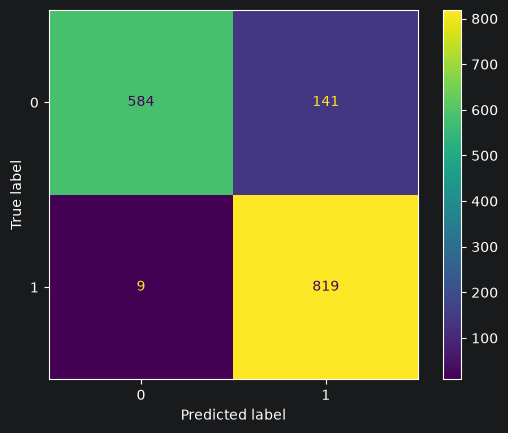

In [17]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
con_mat=confusion_matrix(true_class,pred_class)
print(con_mat)
disp=ConfusionMatrixDisplay(con_mat)
disp.plot()

In [18]:
from sklearn.metrics import classification_report
print(classification_report(true_class,pred_class))

              precision    recall  f1-score   support

           0       0.98      0.81      0.89       725
           1       0.85      0.99      0.92       828

    accuracy                           0.90      1553
   macro avg       0.92      0.90      0.90      1553
weighted avg       0.91      0.90      0.90      1553



True_class is like y_test and pred_class is like y_pred which was used in supervised classification

In [19]:
#inference time
start_time=time.time()
prediction=model.predict(tst_generator)
end_time=time.time()
inference_time=(end_time-start_time)
print(f'Inference time:{inference_time:.2f} ms')

 4/49 ━━━━━━━━━━━━━━━━━━━━ 22s 494ms/step

C:\Users\MADHUMITA\anaconda3\envs\jupyter-python\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


49/49 ━━━━━━━━━━━━━━━━━━━━ 27s 541ms/step
Inference time:26.84 ms


For edge deployment quantization is recommended and also by using tensorflow Lite the compression is high. Reducing the pixels can also help improve the model performance.
Hardware with high computation speed can also be used to improve the model performance.